In [1]:
from __future__ import annotations
import operator
import os
from dotenv import load_dotenv
load_dotenv()
from typing import TypedDict,List,Annotated,Literal,Optional
from pydantic import BaseModel,Field
from langgraph.graph import StateGraph,START,END
from langgraph.types import Send

from langchain_groq import ChatGroq
from langchain_core.messages import SystemMessage,HumanMessage
from tavily import TavilyClient

c:\Neutron\Gen_AI\Projects\1_blog_writing_agent\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
os.environ["LANGCHAIN_API_KEY"] = os.getenv("LANGCHAIN_API_KEY", "")
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGSMITH_PROJECT"] = "Blog Writing Agent with research capabilities"
os.environ["LANGSMITH_ENDPOINT"] = os.getenv("LANGSMITH_ENDPOINT", "")

In [30]:
llm = ChatGroq(
    model="qwen/qwen3-32b",
    temperature=0)

In [31]:
llm

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 16384, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x00000275811C1F00>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000027581630E80>, model_name='qwen/qwen3-32b', temperature=1e-08, model_kwargs={}, groq_api_key=SecretStr('**********'))

In [32]:
#  Schemas
class Task(BaseModel):
    id: int
    title: str

    goal: str = Field(
        ...,
        description="One sentence describing what the reader should be able to do/understand after this section.",
    )
    bullets: List[str] = Field(
        ...,
        min_length=3,
        max_length=6,
        description="3-6 concrete, non-overlapping subpoints to cover in this section.",
    )
    target_words: int = Field(..., description="Target word count for this section (120-550).")

    tags: List[str] = Field(default_factory=list)
    requires_research: bool = False
    requires_citations: bool = False
    requires_code: bool = False


class Plan(BaseModel):
    blog_title: str
    audience: str
    tone: str
    blog_kind: Literal["explainer", "tutorial", "news_roundup", "comparison", "system_design"] = "explainer"
    constraints: List[str] = Field(default_factory=list)
    tasks: List[Task]


class EvidenceItem(BaseModel):
    title: str
    url: str
    published_at: Optional[str] = None  # keep if Tavily provides; DO NOT rely on it
    snippet: Optional[str] = None
    source: Optional[str] = None


class RouterDecision(BaseModel):
    needs_research: bool
    mode: Literal["closed_book", "hybrid", "open_book"]
    queries: List[str] = Field(default_factory=list)


class EvidencePack(BaseModel):
    evidence: List[EvidenceItem] = Field(default_factory=list)

In [33]:
class State(TypedDict):
    topic: str

    # routing / research
    mode: str
    needs_research: bool
    queries: List[str]
    evidence: List[EvidenceItem]
    plan: Optional[Plan]

    # workers
    sections: Annotated[List[tuple[int, str]], operator.add]  # (task_id, section_md)
    final: str

In [34]:
# Router (decide upfront)
ROUTER_SYSTEM = """You are a routing module for a technical blog planner.

Decide whether web research is needed BEFORE planning.

Modes:
- closed_book (needs_research=false):
  Evergreen topics where correctness does not depend on recent facts (concepts, fundamentals).
- hybrid (needs_research=true):
  Mostly evergreen but needs up-to-date examples/tools/models to be useful.
- open_book (needs_research=true):
  Mostly volatile: weekly roundups, "this week", "latest", rankings, pricing, policy/regulation.

If needs_research=true:
- Output 3-5 high-signal queries.
- Queries should be scoped and specific (avoid generic queries like just "AI" or "LLM").
- If user asked for "last week/this week/latest", reflect that constraint IN THE QUERIES.
"""

def router_node(state: State) -> dict:
    
    topic = state["topic"]
    decider = llm.with_structured_output(RouterDecision)
    decision = decider.invoke(
        [
            SystemMessage(content=ROUTER_SYSTEM),
            HumanMessage(content=f"Topic: {topic}"),
        ]
    )

    return {
        "needs_research": decision.needs_research,
        "mode": decision.mode,
        "queries": decision.queries,
    }

def route_next(state: State) -> str:
    return "research" if state["needs_research"] else "orchestrator"

In [35]:
import os

tavily_api=os.getenv("TAVILY_API_KEY")


In [36]:
import os
from typing import Literal

from langchain_core.tools import tool
tavily_client = TavilyClient(api_key=tavily_api)
from tavily import TavilyClient
# @tool
# def internet_search(
#     query: str,
#     max_results: int = 3,
#     chunks_per_source: int=3
#     # topic: Literal["general", "news", "finance"] = "general",
#     # include_raw_content: bool = False,
# ):
#     """Run a web search"""
#     return tavily_client.search(
#         query,
#         max_results=max_results,
#         chunks_per_source=chunks_per_source
#         # include_raw_content=include_raw_content,
#         # topic=topic,
#     )

In [37]:
# tavily_client.search(query="Recent updates in langchain",max_results=5)

In [38]:
# tavily_client = TavilyClient(api_key=tavily_api)
    
# tools = [internet_search]


In [39]:
# researcher=llm.bind_tools(tools)

In [40]:
# from pydantic import BaseModel, Field
# from typing import List, Optional

# class ResearchItem(BaseModel):
#     title: str
#     url: str
#     snippet: str
#     source: str
#     published_at: Optional[str] = "unknown"

# class ResearchOutput(BaseModel):
#     query: str
#     results: List[ResearchItem]


In [41]:
# structured_llm = llm.with_structured_output(ResearchOutput)

In [42]:
# def _tavily_search(query: str, max_results: int = 3):
#     results = tavily_client.search(
#         query=query,
#         max_results=max_results,
#         chunks_per_source=2
#     )
#     return results.get("results", [])

In [43]:
# Research (Tavily) 
from typing import List, Dict
from tavily import TavilyClient
import json

def _tavily_search(query: str, max_results: int = 3) -> List[Dict]:
    """Run Tavily search through tool calling and normalize results."""

    results = tavily_client.search(
        query=query,
        max_results=max_results,
        chunks_per_source=2
    )
    
    normalized: List[Dict] = []

    for r in results:

        if not isinstance(r, dict):
            continue

        normalized.append(
            {
                "title": r.get("title", ""),
                "url": r.get("url", ""),
                "snippet": (r.get("content") or r.get("snippet") or "")[:500],
                "published_at": r.get("published_date") or r.get("published_at"),
                "source": r.get("source"),
                "score": r.get("score"),
            }
        )

    return normalized

    

RESEARCH_SYSTEM = """You are a research synthesizer for technical writing.

Given raw web search results, produce a deduplicated list of EvidenceItem objects.

Rules:
- Only include items with a non-empty url.
- Prefer relevant + authoritative sources (company blogs, docs, reputable outlets).
- If a published date is explicitly present in the result payload, keep it as YYYY-MM-DD.
  If missing or unclear, set published_at=null. Do NOT guess.
- Keep snippets short.
- Deduplicate by URL.
"""

def research_node(state: State) -> dict:

    # take the first 3 queries from state
    queries = (state.get("queries", []) or [])[:3]
    max_results = 3

    raw_results: List[dict] = []

    for q in queries:
        raw_results.extend(_tavily_search(q, max_results=max_results))

    if not raw_results:
        return {"evidence": []}

    extractor = llm.with_structured_output(EvidencePack)
    pack = extractor.invoke(
        [
            SystemMessage(content=RESEARCH_SYSTEM),
            HumanMessage(content="Raw results:\n" + json.dumps(raw_results, indent=2)),
        ]
    )

    # Deduplicate by URL
    dedup = {}
    for e in pack.evidence:
        if e.url:
            dedup[e.url] = e

    return {"evidence": list(dedup.values())}

In [44]:
# Orchestrator (Plan)

ORCH_SYSTEM = """You are a senior technical writer and developer advocate.
Your job is to produce a highly actionable outline for a technical blog post.

Hard requirements:
- Create 5-9 sections (tasks) suitable for the topic and audience.
- Each task must include:
  1) goal (1 sentence)
  2) 3-6 bullets that are concrete, specific, and non-overlapping
  - EACH section MUST contain **3 to 5 bullets**.
  - NEVER output fewer than 3 bullets.
  3) target word count (120-450)

Quality bar:
- Assume the reader is a developer; use correct terminology.
- Bullets must be actionable: build/compare/measure/verify/debug.
- Ensure the overall plan includes at least 2 of these somewhere:
  * minimal code sketch / MWE (set requires_code=True for that section)
  * edge cases / failure modes
  * performance/cost considerations
  * security/privacy considerations (if relevant)
  * debugging/observability tips

Grounding rules:
- Mode closed_book: keep it evergreen; do not depend on evidence.
- Mode hybrid:
  - Use evidence for up-to-date examples (models/tools/releases) in bullets.
  - Mark sections using fresh info as requires_research=True and requires_citations=True.
- Mode open_book:
  - Set blog_kind = "news_roundup".
  - Every section is about summarizing events + implications.
  - DO NOT include tutorial/how-to sections unless user explicitly asked for that.
  - If evidence is empty or insufficient, create a plan that transparently says "insufficient sources"
    and includes only what can be supported.

Output must strictly match the Plan schema.
"""

def orchestrator_node(state: State) -> dict:
    planner = llm.with_structured_output(Plan)

    evidence = state.get("evidence", [])
    mode = state.get("mode", "closed_book")

    plan = planner.invoke(
        [
            SystemMessage(content=ORCH_SYSTEM),
            HumanMessage(
                content=(
                    f"Topic: {state['topic']}\n"
                    f"Mode: {mode}\n\n"
                    f"Evidence (ONLY use for fresh claims; may be empty):\n"
                    f"{[e.model_dump() for e in evidence][:6]}"
                )
            ),
        ]
    )

    return {"plan": plan}

In [45]:
# Fanout

def fanout(state: State):
    return [
        Send(
            "worker",
            {
                "task": task.model_dump(),
                "topic": state["topic"],
                "mode": state["mode"],
                "plan": state["plan"].model_dump(),
                "evidence": [e.model_dump() for e in state.get("evidence", [])],
            },
        )
        for task in state["plan"].tasks
    ]

In [46]:
def select_relevant_evidence(task, evidence):
    keywords = set(task.title.lower().split() + task.goal.lower().split())
    return [
        e for e in evidence
        if any(k in (e.title.lower() + (e.snippet or "").lower()) for k in keywords)
    ][:3]

In [47]:
# Worker (write one section)

WORKER_SYSTEM = """You are a senior technical writer and developer advocate.
Write ONE section of a technical blog post in Markdown.

Hard constraints:
- Follow the provided Goal and cover ALL Bullets in order (do not skip or merge bullets).
- Stay close to Target words (±5%).
- Output ONLY the section content in Markdown (no blog title H1, no extra commentary).
- Start with a '## <Section Title>' heading.

Scope guard:
- If blog_kind == "news_roundup": do NOT turn this into a tutorial/how-to guide.
  Do NOT teach web scraping, RSS, automation, or "how to fetch news" unless bullets explicitly ask for it.
  Focus on summarizing events and implications.

Grounding policy:
- If mode == open_book:
  - Do NOT introduce any specific event/company/model/funding/policy claim unless it is supported by provided Evidence URLs.
  -If evidence is insufficient → explicitly say:
    "Not enough evidence to support this claim."
  - For each event claim, attach a source as a Markdown link: ([Source](URL)).
  - Only use URLs provided in Evidence. If not supported, write: "Not found in provided sources."
- If requires_citations == true:
  - For outside-world claims, cite Evidence URLs the same way.
- Evergreen reasoning is OK without citations unless requires_citations is true.

Code:
- If requires_code == true, include at least one minimal, correct code snippet relevant to the bullets.

Style:
- Short paragraphs, bullets where helpful, code fences for code.
- Avoid fluff/marketing. Be precise and implementation-oriented.
"""

def worker_node(payload: dict) -> dict:
    
    task = Task(**payload["task"])
    plan = Plan(**payload["plan"]) 

    raw_evidence = payload.get("evidence", [])

    evidence = [
        e.model_dump() if hasattr(e, "model_dump") else e
        for e in select_relevant_evidence(task, raw_evidence)
    ]

    evidence_text = ""
    if evidence:
        evidence_text = "\n".join(
            f"- {e.get('title','')} | {e.get('url','')} | {e.get('published_at') or 'date:unknown'}"
            for e in evidence[:5]
        )

    topic = payload["topic"]
    mode = payload.get("mode", "closed_book")

    bullets_text = "\n- " + "\n- ".join(task.bullets)
    section_md = llm.invoke(
        [
            SystemMessage(content=WORKER_SYSTEM),
            HumanMessage(
                content=(
                    f"Blog title: {plan.blog_title}\n"
                    f"Audience: {plan.audience}\n"
                    f"Tone: {plan.tone}\n"
                    f"Blog kind: {plan.blog_kind}\n"
                    f"Constraints: {plan.constraints}\n"
                    f"Topic: {topic}\n"
                    f"Mode: {mode}\n\n"
                    f"Section title: {task.title}\n"
                    f"Goal: {task.goal}\n"
                    f"Target words: {task.target_words}\n"
                    f"Tags: {task.tags}\n"
                    f"requires_research: {task.requires_research}\n"
                    f"requires_citations: {task.requires_citations}\n"
                    f"requires_code: {task.requires_code}\n"
                    f"Bullets:{bullets_text}\n\n"
                    f"Evidence (ONLY use these URLs when citing):\n{evidence_text}\n"
                )
            ),
        ]
    ).content.strip()

    return {"sections": [(task.id, section_md)]}

In [48]:
# Reducer (merge + save)
from pathlib import Path
import re
def reducer_node(state: State) -> dict:

    plan = state["plan"]
    title=plan.blog_title
    ordered_sections = [md for _, md in sorted(state["sections"], key=lambda x: x[0])]
    body = "\n\n".join(ordered_sections).strip()
    final_md = f"# {plan.blog_title}\n\n{body}\n"

    safe_title = re.sub(r"[^a-zA-Z0-9 ]", "", title)
    filename = safe_title.lower().replace(" ", "_") + ".md"
    # filename = title.lower().replace(" ","_")+".md"
    Path(filename).write_text(final_md, encoding="utf-8")

    return {"final": final_md}

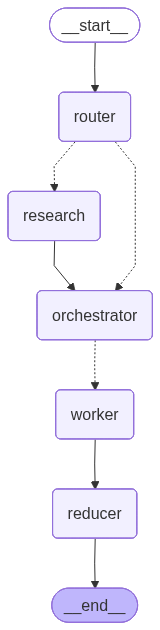

In [49]:
# Build graph

g = StateGraph(State)
g.add_node("router", router_node)
g.add_node("research", research_node)
g.add_node("orchestrator", orchestrator_node)
g.add_node("worker", worker_node)
g.add_node("reducer", reducer_node)

g.add_edge(START, "router")
g.add_conditional_edges("router", route_next, {"research": "research", "orchestrator": "orchestrator"})
g.add_edge("research", "orchestrator")

g.add_conditional_edges("orchestrator", fanout, ["worker"])
g.add_edge("worker", "reducer")
g.add_edge("reducer", END)

app = g.compile()
app

In [50]:
# Runner

def run(topic: str):
    out = app.invoke(
        {
            "topic": topic,
            "mode": "",
            "needs_research": False,
            "queries": [],
            "evidence": [],
            "plan": None,
            "sections": [],
            "final": "",
        }
    )

    return out

In [51]:
run("Self attention mechanism")

{'topic': 'Self attention mechanism',
 'mode': 'closed_book',
 'needs_research': False,
 'queries': ['Explanation of self-attention mechanism in transformers',
  'How self-attention enables long-range dependencies',
  'Comparison of self-attention vs recurrence mechanisms'],
 'evidence': [],
 'plan': Plan(blog_title='Mastering Self-Attention Mechanisms in Transformers', audience='Developers with ML experience', tone='Technical', blog_kind='explainer', constraints=['Closed-book mode', 'No external citations'], tasks=[Task(id=1, title='Understanding Self-Attention Fundamentals', goal='Define self-attention and its role in transformer architectures', bullets=['Explain the query-key-value triplet mechanism', 'Compare with traditional RNN/attention mechanisms', 'Show mathematical formulation of attention scores'], target_words=300, tags=['basics'], requires_research=False, requires_citations=False, requires_code=True), Task(id=2, title='Mathematical Breakdown of Attention Calculations', goa